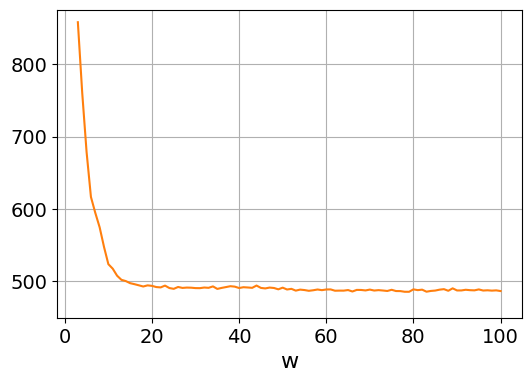

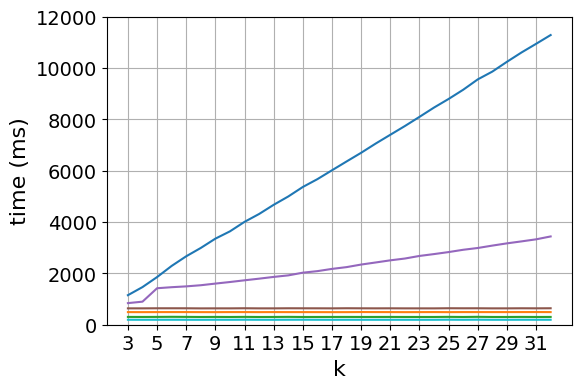

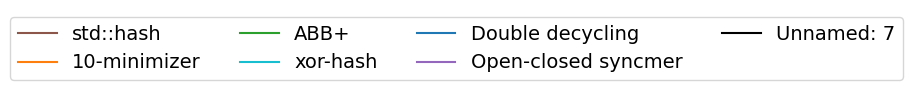

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- Configuration ----
drop_gm_cols = True  # set to True to suppress any column whose name contains "_gm"
k_min = 3
k_max = 32
y_lim_min_1st_plot = 450
y_lim_max_1st_plot = 875

y_lim_min_2nd_plot = 0
y_lim_max_2nd_plot = 12000

# Name mapping for legend
name_map = {
    "time_random": "xor-hash",
    "time_random_std": "std::hash",
    "time_abb_plus": "ABB+",
    "time_lazy": "10-minimizer",
    "time_dd": "Double decycling",
    "time_oc": "Open-closed syncmer"
}

# ---- Load data ----
df_w = pd.read_csv("lazy_runtime_w_scaling.csv")
df_k = pd.read_csv("sampling_runtime_k_scaling.csv")

if drop_gm_cols:
    df_k = df_k[[c for c in df_k.columns if "_gm" not in c]]

# Filter k range
df_k = df_k[(df_k["k"] >= k_min) & (df_k["k"] <= k_max)]

# ---- Plot 1: lazy_runtime_w_scaling.csv (w vs time_lazy_ms) ----
fig1, ax1 = plt.subplots(figsize=(6, 4))
line_10_min, = ax1.plot(df_w["w"], df_w["time_lazy_ms"], color="tab:orange")
color_10_min = "tab:orange"
ax1.set_xlabel("w", fontsize=16)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.set_ylim(y_lim_min_1st_plot, y_lim_max_1st_plot)
ax1.grid(True)
fig1.savefig("runtime_plot_w.svg", format="svg", bbox_inches="tight")

# ---- Plot 2: sampling_runtime_k_scaling.csv (k vs runtimes) ----
fig2, ax2 = plt.subplots(figsize=(6, 4))

# All time columns except 'k'
time_cols = [c for c in df_k.columns if c != "k"]

# Desired order for the legend
order_map = {"std::hash": 0, "10-minimizer": 1, "ABB+": 2, "xor-hash": 3, "Double decycling": 4, "Open-closed syncmer": 5}
time_cols.sort(key=lambda c: order_map.get(name_map.get(c, c), 99))

# Map specific names to colors to align with minimizer_density_comparison.ipynb
color_map = {
    "10-minimizer": "tab:orange",
    "ABB+": "tab:green",
    "std::hash": "tab:brown",
    "xor-hash": "tab:cyan",
    "Double decycling": "tab:blue",
    "Open-closed syncmer": "tab:purple",
    "Miniception": "tab:red"
}

for col in time_cols:
    label_name = name_map.get(col, col)
    if col == "time_oc":
        # Open-closed syncmer: time is for both OC and Miniception, so alternate segment colors
        k_vals = df_k["k"].values
        y_vals = df_k[col].values
        for i in range(len(k_vals) - 1):
            color = "tab:purple" if i % 2 == 0 else "tab:red"
            ax2.plot(k_vals[i:i+2], y_vals[i:i+2], color=color)
        # Single legend entry (use first segment's color for the handle)
        ax2.plot([], [], color="tab:purple", label=label_name)
    else:
        ax2.plot(df_k["k"], df_k[col], label=label_name, color=color_map.get(label_name, "black"))

ax2.set_xlabel("k", fontsize=16)
ax2.set_ylabel("time (ms)", fontsize=16)
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.set_ylim(y_lim_min_2nd_plot, y_lim_max_2nd_plot)
ax2.grid(True)
fig2.savefig("runtime_plot_k.svg", format="svg", bbox_inches="tight")

# ---- Plot 3: Separate Legend ----
fig_leg = plt.figure(figsize=(8, 1))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')
handles, labels = ax2.get_legend_handles_labels()
ax_leg.legend(handles, labels, loc='center', ncol=4, fontsize=14)
fig_leg.savefig("runtime_plot_legend.svg", format="svg", bbox_inches="tight")

# x-ticks every 2nd number starting from k_min
xticks = range(k_min, k_max + 1, 2)
ax2.set_xticks(xticks)

plt.show()